In [1]:
import os
import numpy as np
import cvxpy as cp
from sklearn.cluster import SpectralClustering
import mosek

import utils

SAVE = False
PREFIX = './results/sem_new_data'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (0.000, 1.000)  - Y: (-0.998, 1.000)  -  data: (-0.998, 1.000)
Mean value of: X: 0.416  -  Y: 0.001  -  data: 0.409
Std value of: X: 0.240  -  Y: 0.577  -  data: 0.254


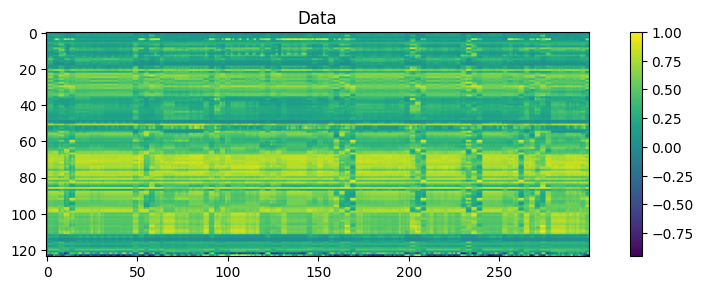

In [2]:
Data = utils.load_accoustic_data()
N, M = Data.shape

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (-7.201, 18.151)  - Y: (-1.731, 1.732)  -  data: (-7.201, 18.151)
Mean value of: X: 0.000  -  Y: -0.000  -  data: 0.000
Std value of: X: 1.000  -  Y: 1.000  -  data: 1.000


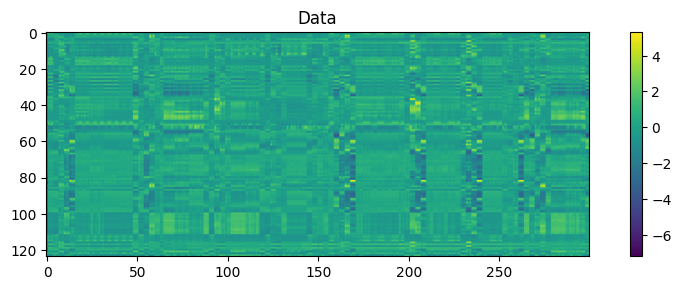

In [3]:
Data = utils.load_accoustic_data(all_data=True)
N, M = Data.shape

## Undirected SEM

In [ ]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = [1e3]  # [0, 500, 1e3, 2.5e3, 5e3, 7.5e3]
A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A = cp.Variable((N,N), symmetric=True)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(A)
    constr = [A >= 0, A[np.eye(N, dtype=bool)] == 0]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')

    A_est = A.value
    A_est /= np.max(np.abs(A_est))

    A_undir_sem.append(A_est)

Lamb (mult): 63.0125 (1000.0)  - status: optimal


### Threshold = 0.05

In [ ]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     # Load the precomputed data
#     file_name = PREFIX + f'/sem_und_{lamb0}.npz.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]

FileNotFoundError: [Errno 2] No such file or directory: './results/sem_new_data/sem_und_159.78.npz.npy'

- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.067


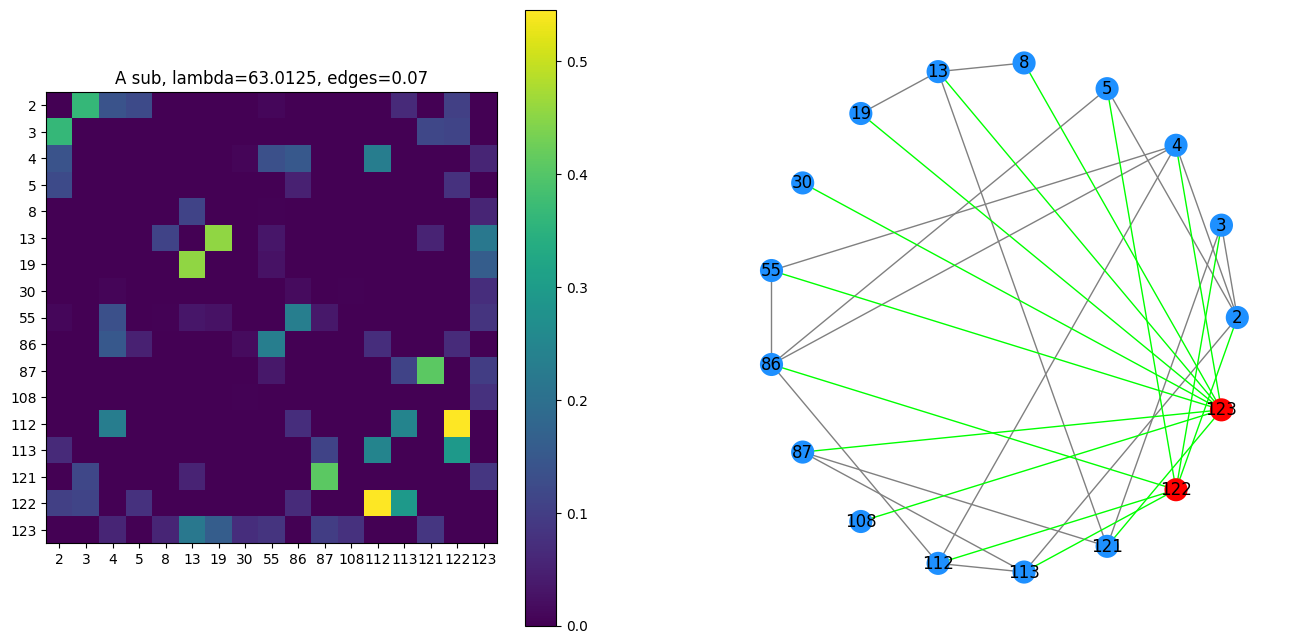

In [ ]:
# Plot A
th = 0.05
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_und{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, save=SAVE, file_name=file_name)

## Directed SEM

In [6]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

Mults = [0, 1e3, 1500, 2.5e3, 5e3] #[0, 25, 250, 500, 700, 800, 1e3]
Dir_sem = []
for mult in Mults:
    lamb = mult*lamb0
    
    A = cp.Variable((N,N), symmetric=False)
    obj = cp.sum_squares(A@Data - Data) + lamb*cp.sum(A)
    constr = [A >= 0, A[np.eye(N, dtype=bool)] == 0]

    prob = cp.Problem(cp.Minimize(obj), constr)
    obj = prob.solve(solver='MOSEK', verbose=False)

    print(f'Lamb (mult): {lamb:.4f} ({mult})  - status: {prob.status}')
    
    A_est = A.value
    A_est /= np.max(np.abs(A_est))

    Dir_sem.append(A_est)

Lamb (mult): 0.0000 (0)  - status: optimal
Lamb (mult): 63.0125 (1000.0)  - status: optimal
Lamb (mult): 94.5188 (1500)  - status: optimal
Lamb (mult): 157.5313 (2500.0)  - status: optimal
Lamb (mult): 315.0626 (5000.0)  - status: optimal


### Threshold = 0.05

- Lamb: 0.0  -  Prop. edges above threshold: 0.078
	 Saved as: ./results/sem_new_data/sem_dir0_0.05
- Lamb: 63.012521738822144  -  Prop. edges above threshold: 0.060
	 Saved as: ./results/sem_new_data/sem_dir1000.0_0.05
- Lamb: 94.51878260823321  -  Prop. edges above threshold: 0.054
	 Saved as: ./results/sem_new_data/sem_dir1500_0.05
- Lamb: 157.53130434705537  -  Prop. edges above threshold: 0.045
	 Saved as: ./results/sem_new_data/sem_dir2500.0_0.05
- Lamb: 315.06260869411074  -  Prop. edges above threshold: 0.034
	 Saved as: ./results/sem_new_data/sem_dir5000.0_0.05


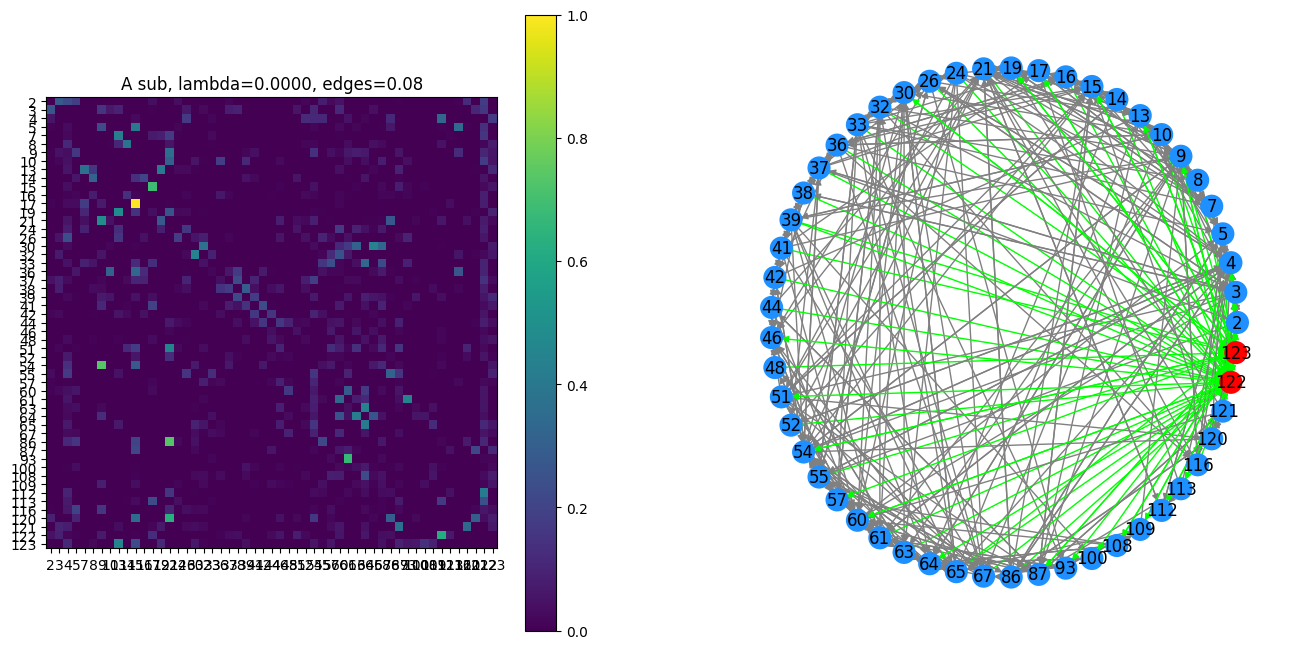

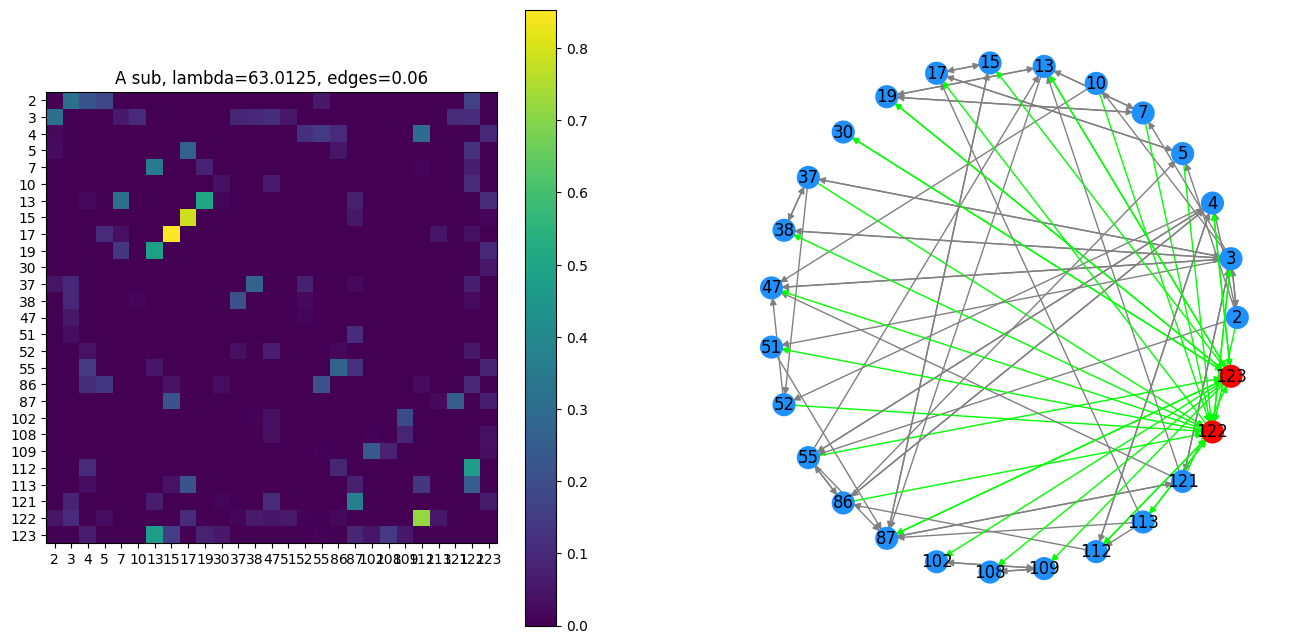

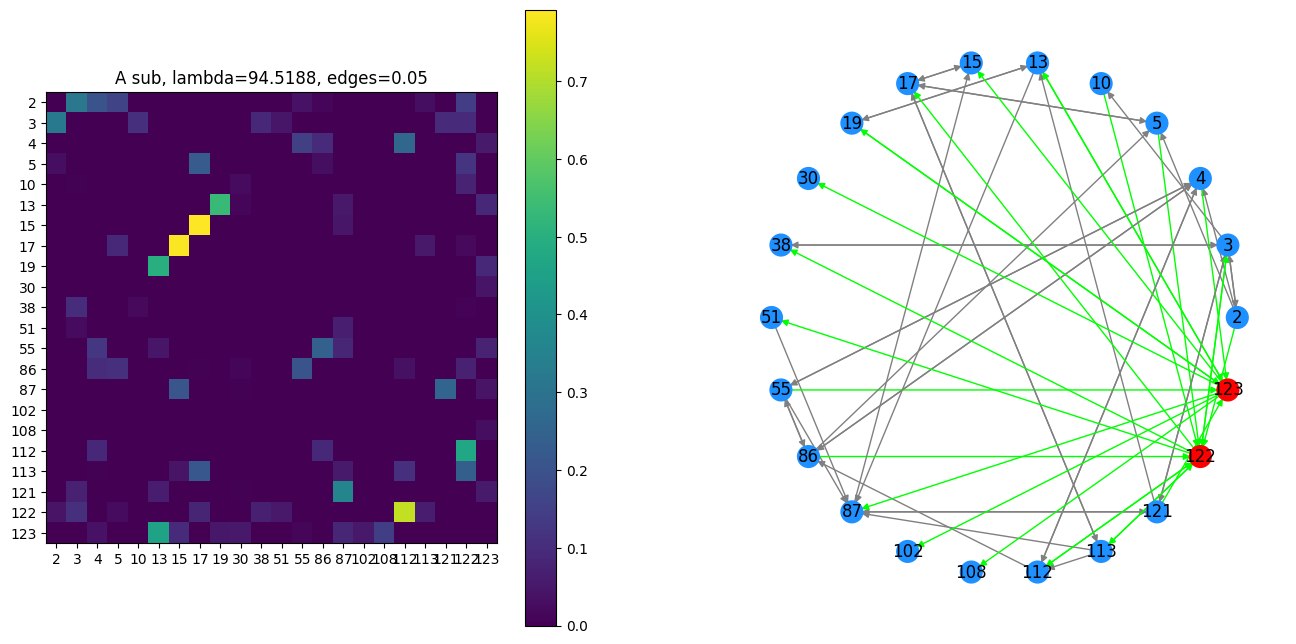

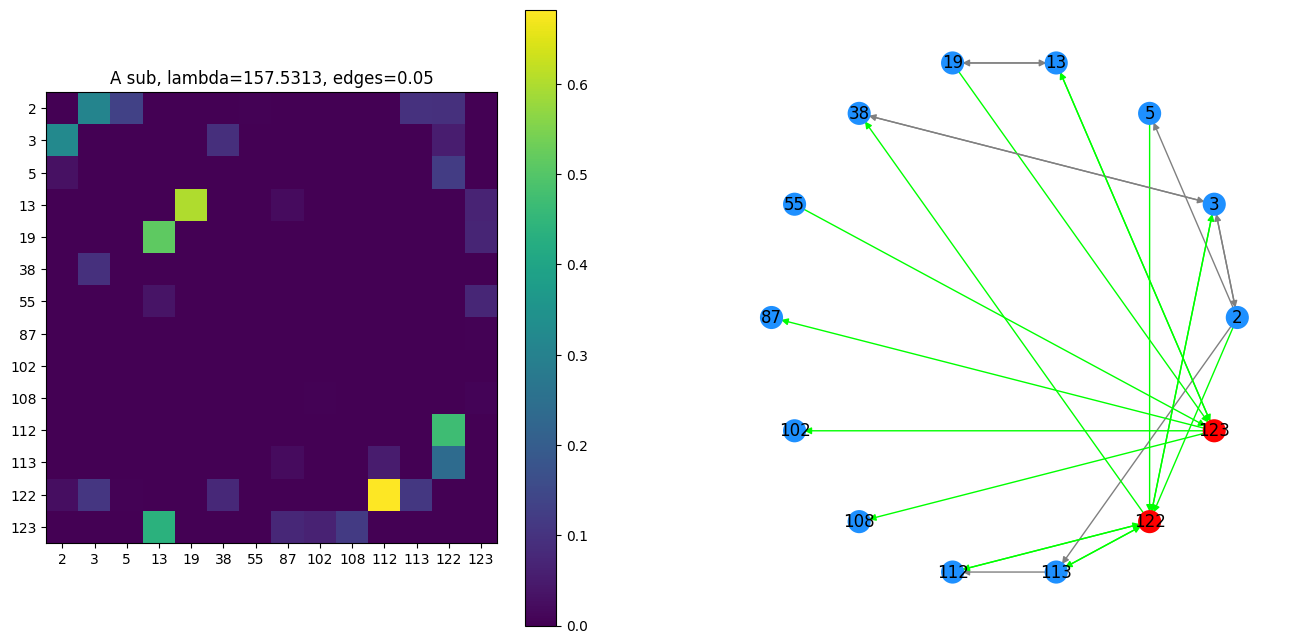

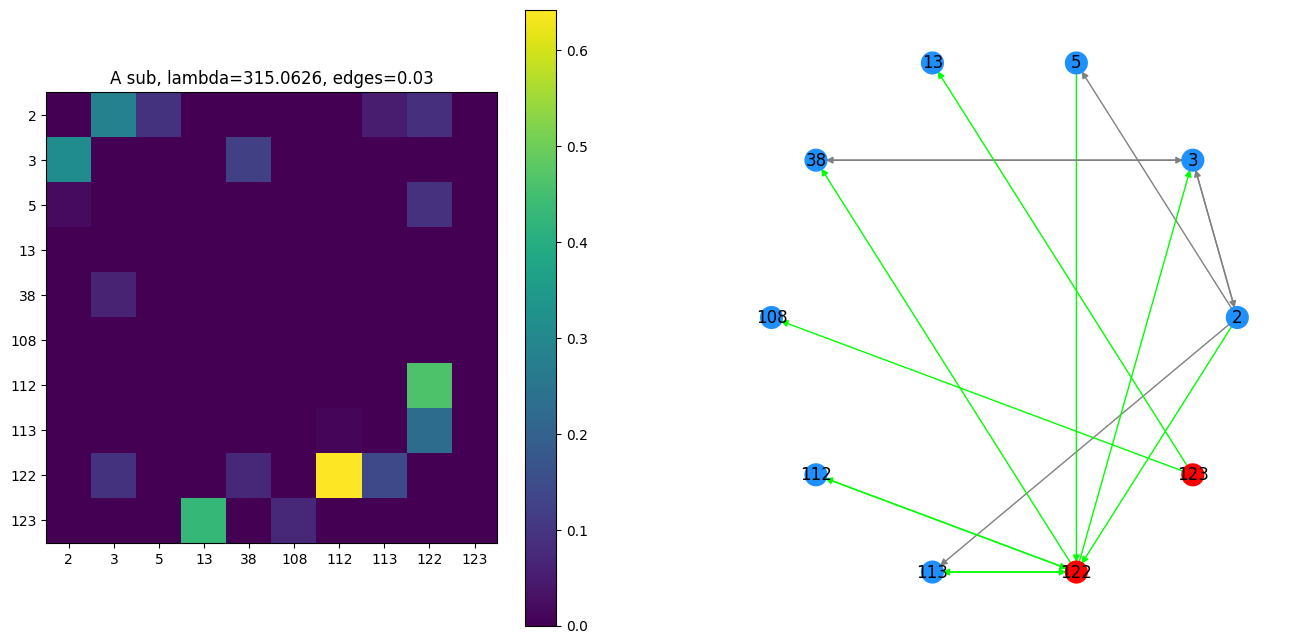

In [7]:
# Plot A
th = 0.05
for i, A_est in enumerate(Dir_sem):
    mult = Mults[i]
    file_name = f'{PREFIX}/sem_dir{mult}_{th}'
    # utils.save_plot_graph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)
    utils.save_plot_subgraph(A_est, th, mult*lamb0, file_name=file_name, save=SAVE, directed=True)